#  Phase 4

## Correlation Matrix & Top Correlated Features

This cell calculates the linear correlation coefficients between all numerical features and the target (SalePrice), extracts the strongest relationships, and visualizes them using a heatmap.

### Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_regression

['Id', 'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'SalePrice_Log']

 no. of numerical column :36
TOP POSITIVE & NEGATIVE CORRELATIONS WITH SALE PRICE
Top Positive Correlators:
 SalePrice       0.954610
GrLivArea       0.718844
GarageCars      0.680408
GarageArea      0.662106
TotalBsmtSF     0.642243
1stFlrSF        0.613742
FullBath        0.590919
YearBuilt       0.588977
YearRemodAdd    0.568986
GarageYrBlt     0.544005
Name: SalePrice_Log, dtype: float64


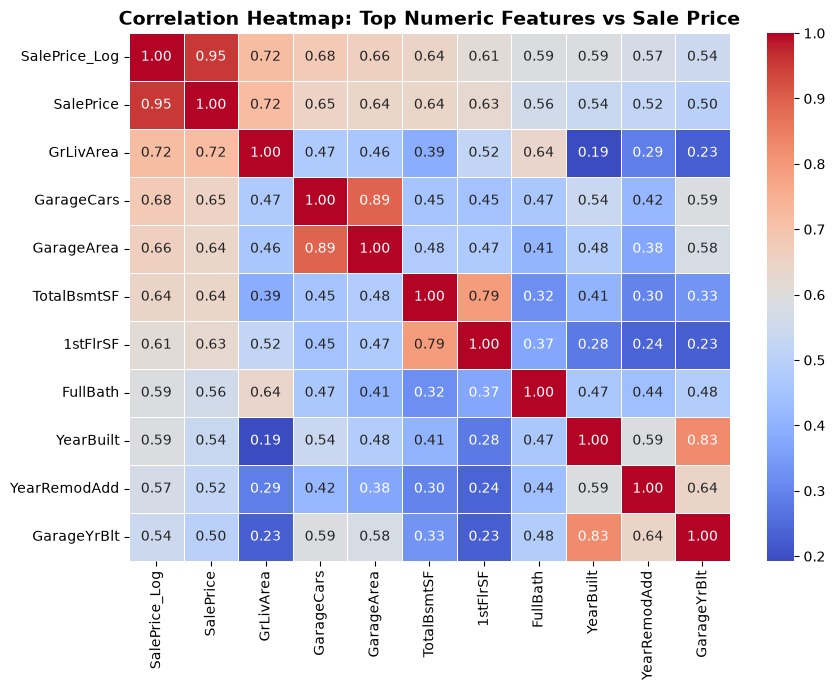

In [2]:

# Ensure we are using your processed training dataset
df =  pd.read_csv('../data/train_processed_phase3.csv')


# ORDINAL COLUMNS (have natural order)
ordinal_cols = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageFinish', 
                'GarageQual', 'GarageCond', 'PavedDrive', 'Functional', 
                'LotShape', 'Utilities', 'LandSlope', 'Fence', 'PoolQC']

# NOMINAL COLUMNS (no order - use get_dummies)
nominal_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotConfig', 
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
                'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
                'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 
                'MiscFeature', 'SaleType', 'SaleCondition', 'LandContour']

# Step 0: Ensure integer-coded nominal columns (like MSSubClass) are treated as strings
for col in nominal_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Step 1: Fill NA in ordinal columns with 'NA' string, then label encode
for col in ordinal_cols:
    if col in df.columns:
        df[col] = df[col].fillna('NA')
        df[col] = df[col].astype('category')  # Converts to 0,1,2... preserving order


# 1. Compute correlation matrix for all numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols.tolist())
print("="*60)
print(f"\n no. of numerical column :{len(numeric_cols)}")
print("="*60)
corr_matrix = df[numeric_cols].corr()

# 2. Extract correlations specifically against SalePrice (or SalePrice_Target)
target_col = 'SalePrice_Log' if 'SalePrice_Log' in df.columns else 'SalePrice'
box_target = 'SalePrice' if 'SalePrice' in df.columns else target_col
saleprice_corr = corr_matrix[target_col].sort_values(ascending=False)

# Top 10 positive (excluding target itself) and top negative correlations
top_positive = saleprice_corr.head(11).iloc[1:]
top_negative = saleprice_corr.tail(10)

print('=' * 80)
print('TOP POSITIVE & NEGATIVE CORRELATIONS WITH SALE PRICE')
print('=' * 80)
print('Top Positive Correlators:\n', top_positive)


# 3. Plot a Correlation Heatmap for the Top Features
plt.figure(figsize=(9, 7))
top_corr_features = saleprice_corr.head(11).index
sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title(
    'Correlation Heatmap: Top Numeric Features vs Sale Price',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()



Top Negative Correlators:
 3SsnPorch        0.056065
PoolArea         0.040679
BsmtFinSF2       0.006420
BsmtHalfBath    -0.014974
MiscVal         -0.019752
Id              -0.020511
YrSold          -0.034319
LowQualFinSF    -0.037698
KitchenAbvGr    -0.147891
EnclosedPorch   -0.148636
Name: SalePrice_Log, dtype: float64


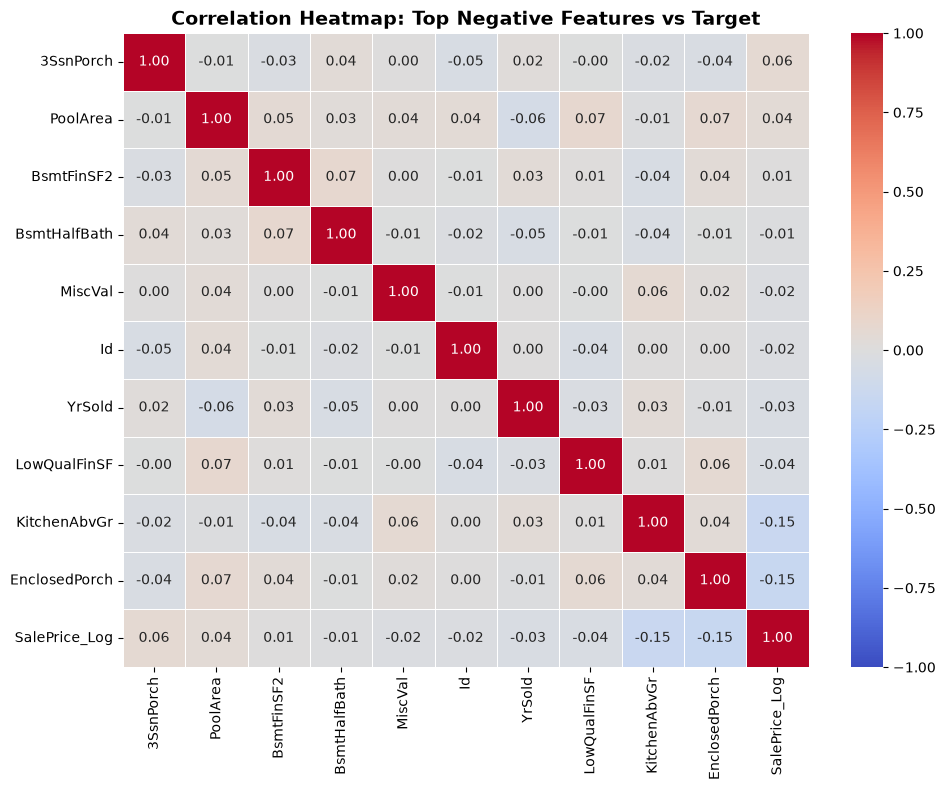

In [3]:

print("="*60)
print('\nTop Negative Correlators:\n', top_negative)

plt.figure(figsize=(10, 8))

# Get the index names of the top negative correlators
top_neg_features = list(top_negative.index)

# Ensure the target column is included in the correlation grid so we can see its relationship with them
if target_col not in top_neg_features:
    top_neg_features.append(target_col)

# Generate and plot the heatmap
sns.heatmap(
    df[top_neg_features].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1.0, 
    vmax=1.0,
    fmt='.2f',
    linewidths=0.5,
)

plt.title(
    'Correlation Heatmap: Top Negative Features vs Target',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## Scatter Plots of the Top 5 Correlated Features


Numerical correlation numbers can sometimes trick you if there are nonlinear curves or extreme outliers. Scatter plots let you visually inspect if the relationship is linear, straight, or shaped weirdly.

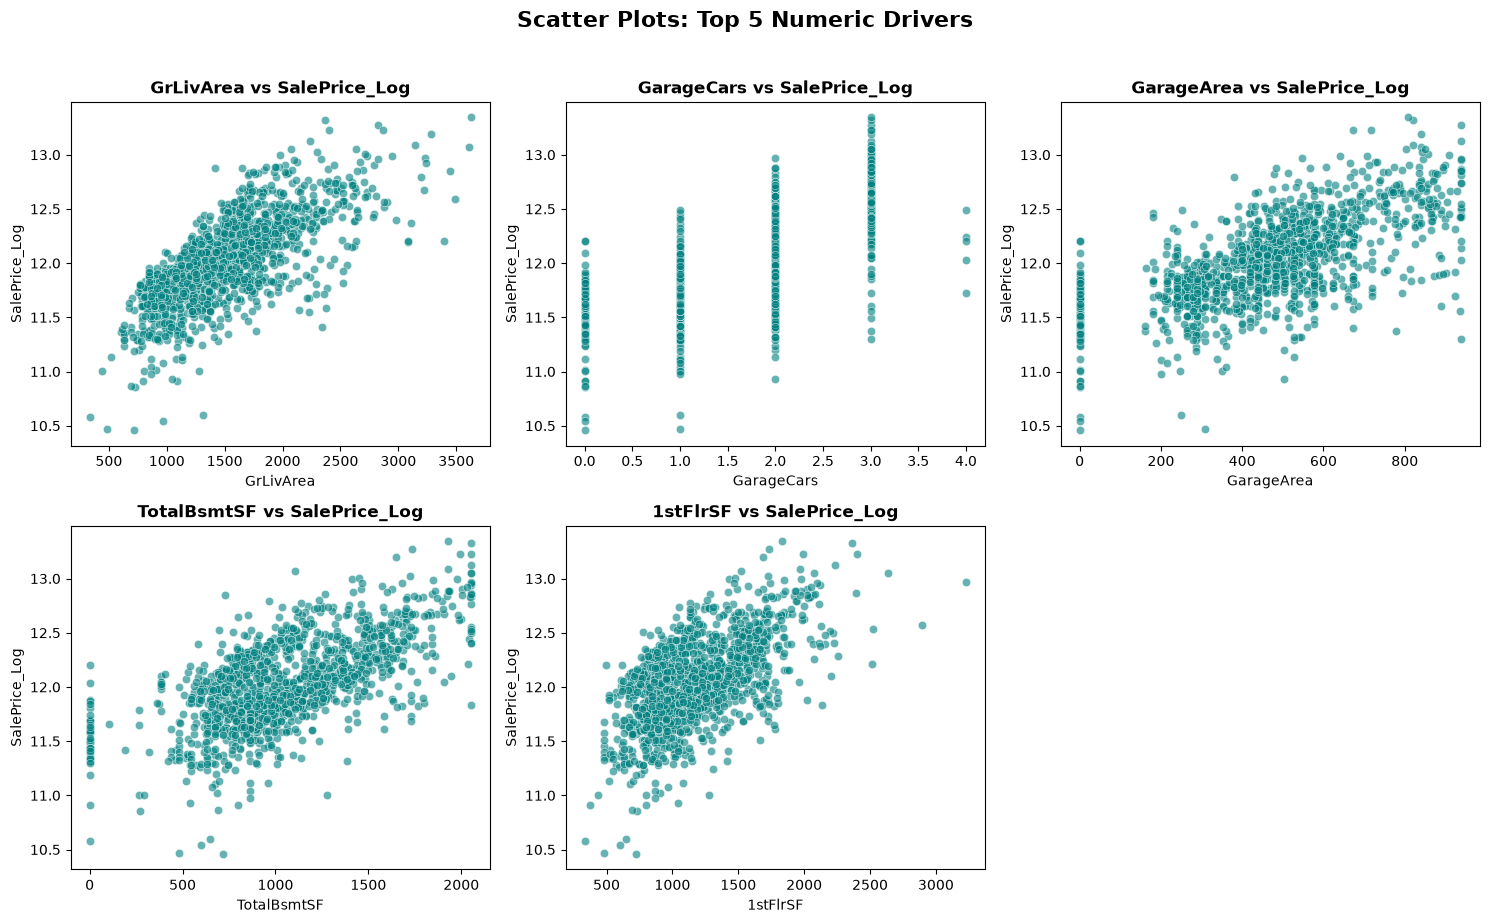

In [4]:
# Extract the names of the top 5 positive numerical drivers
top_5_numeric = top_positive.head(6).index.tolist()

# Create a multi-plot canvas
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(top_5_numeric[1:]):
  sns.scatterplot(
      data=df, x=col, y=target_col, ax=axes[i], color='teal', alpha=0.6
  )
  axes[i].set_title(f'{col} vs {target_col}', fontweight='bold')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel(target_col)

# Hide any unused grid spaces
if len(top_5_numeric)-1 < len(axes):
  axes[-1].set_visible(False)

plt.suptitle(
    'Scatter Plots: Top 5 Numeric Drivers', fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## Boxplots Across Key Categorical Features to check shift of price with category
You won't know if a categorical column like Neighborhood contains powerful pricing shifts or if its sub-categories are completely random.: Draws distribution boxes showing the median, spread, and outliers of house prices grouped by categorical brackets (e.g., how prices change across different neighborhoods or kitchen quality ratings).

bottom 5: ['Street', 'PoolQC', 'Utilities', 'LandContour', 'Condition2']
🏆 TOP 5 ANOVA F-TEST CATEGORICAL FEATURES: ['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'GarageFinish']


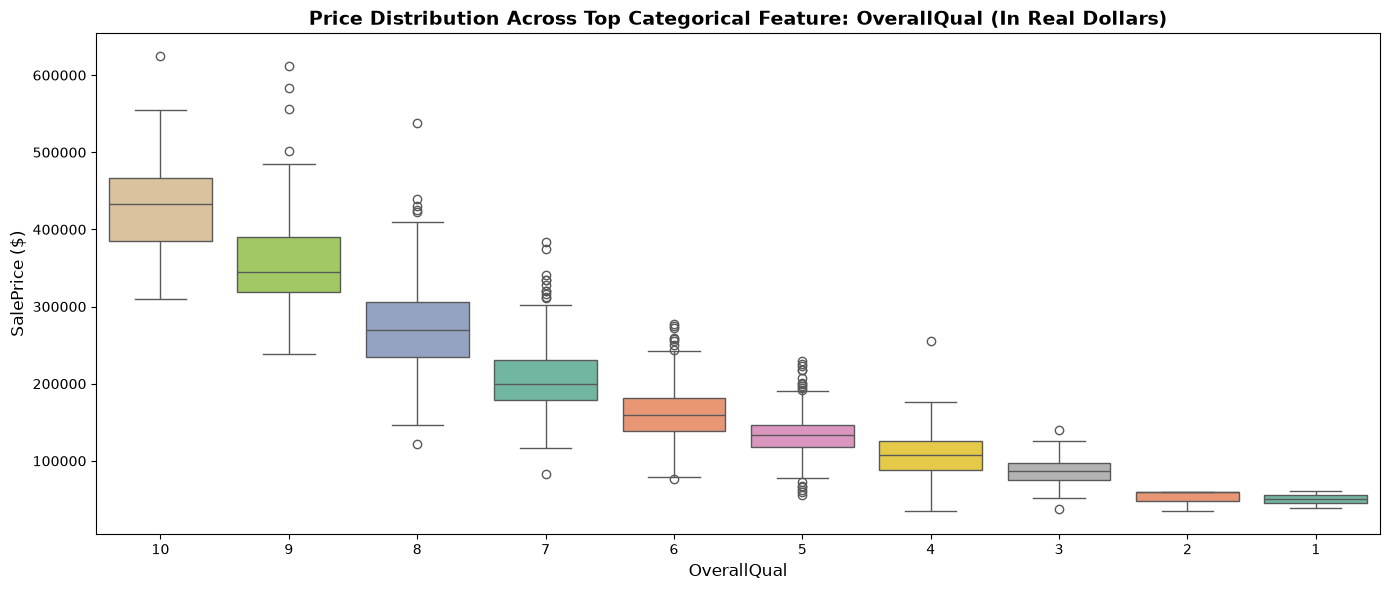

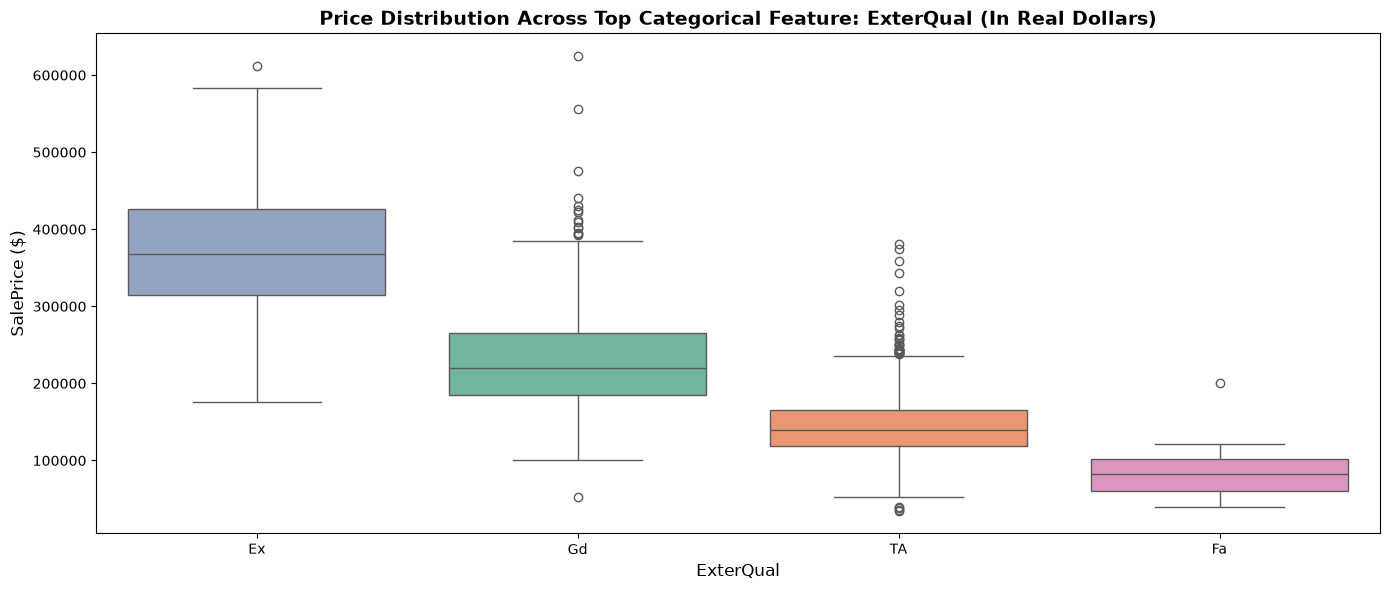

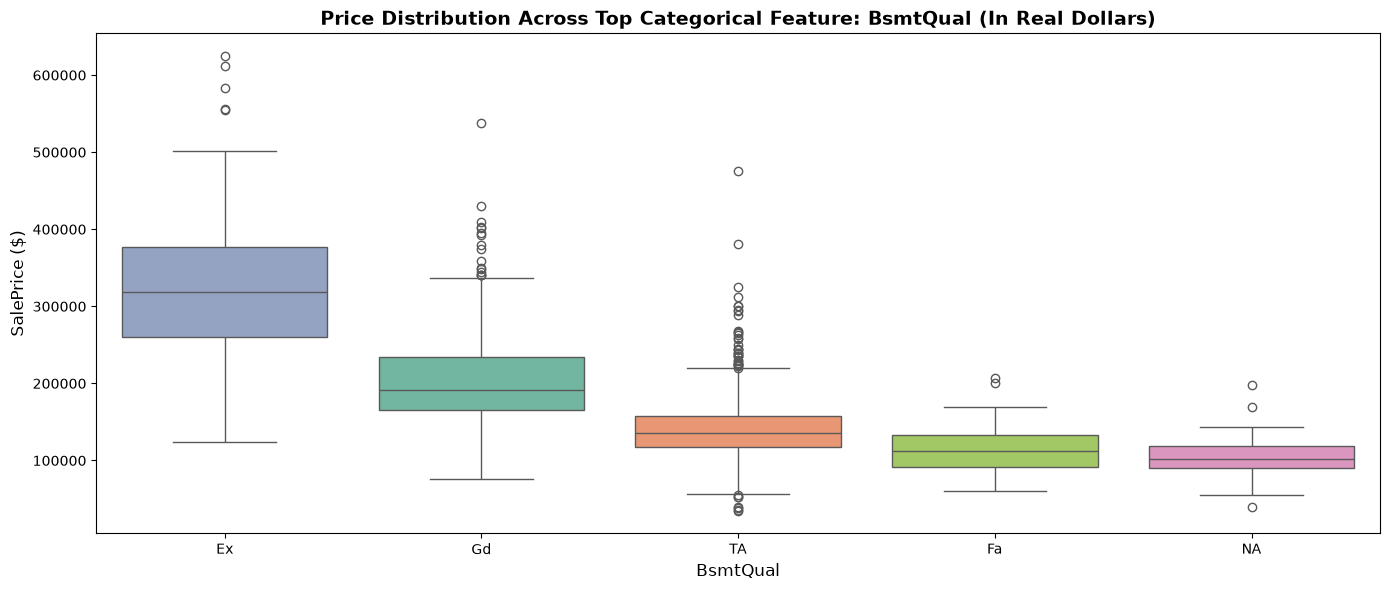

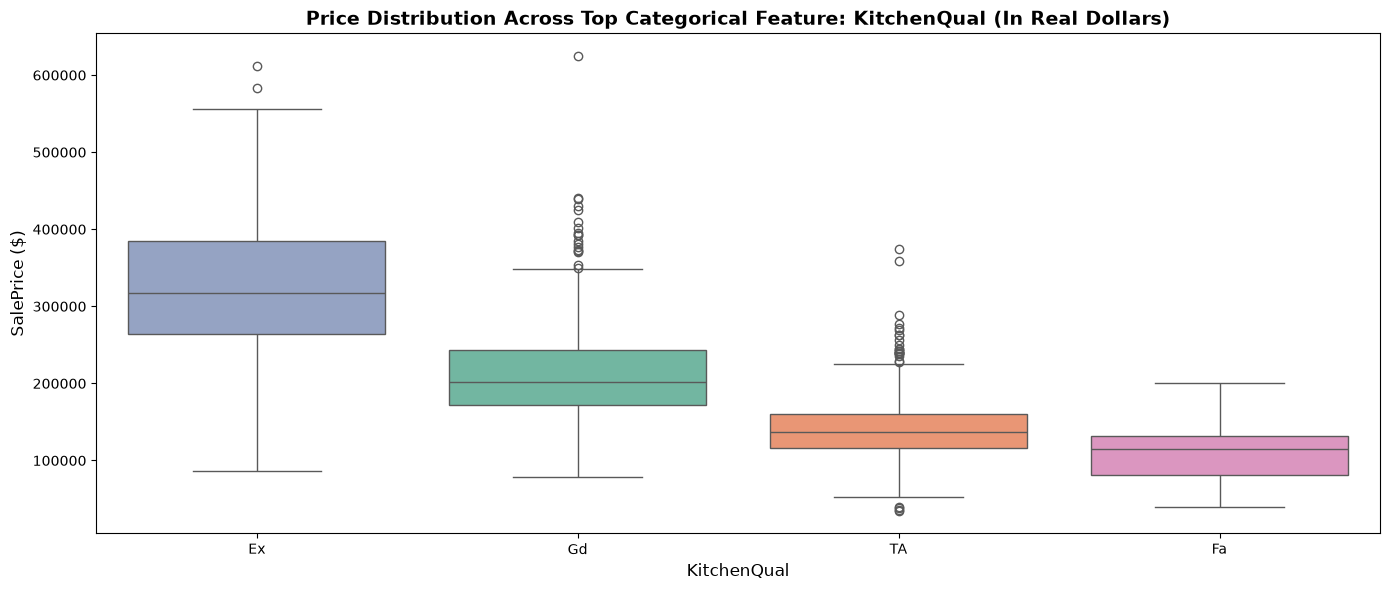

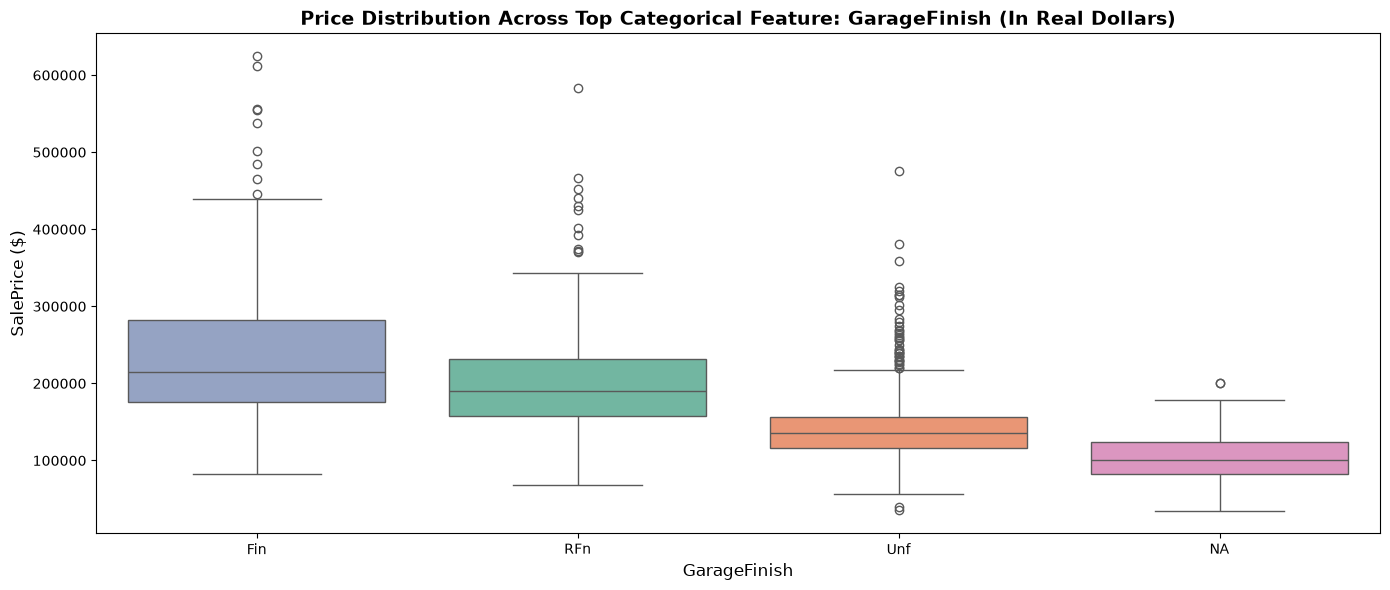

In [5]:
# 1. Combine all available categorical columns that exist in your dataframe
all_categorical_cols = list(
    set(ordinal_cols + nominal_cols).intersection(df.columns)
)

# 2. Score categorical columns using ANOVA F-test (f_regression)
# cat_data = df[all_categorical_cols].fillna('None').astype(str)
encoded_cat = df[all_categorical_cols].apply(LabelEncoder().fit_transform)

f_scores, _ = f_regression(encoded_cat, df[box_target])
cat_importance = pd.Series(f_scores, index=all_categorical_cols).sort_values(ascending=False)

# 3. Automatically select the top 5 most impactful categorical features
top_cats = cat_importance.head(5).index.tolist()
bottom_cat=cat_importance.tail(5).index.to_list()
print(f"bottom 5: {bottom_cat}")

print('=' * 80)
print(f'🏆 TOP 5 ANOVA F-TEST CATEGORICAL FEATURES: {top_cats}')
print('=' * 80)

# 4. Generate clean, sorted boxplots against real SalePrice
for col in top_cats:
    plt.figure(figsize=(14, 6))

    # Convert column to string temporarily to ensure neat distinct x-axis labels
    plot_df = df.copy()
    plot_df[col] = plot_df[col].astype(str)

    # Sort category order by median real house price for a clean, readable layout
    order = (
        plot_df.groupby(col, observed=False)[box_target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=plot_df, 
        x=col, 
        y=box_target, 
        order=order, 
        hue=col, 
        palette='Set2', 
        legend=False
    )
    
    plt.title(
        f'Price Distribution Across Top Categorical Feature: {col} (In Real Dollars)',
        fontsize=14,
        fontweight='bold',
    )
    plt.xlabel(col, fontsize=12)
    plt.ylabel('SalePrice ($)', fontsize=12)
    plt.xticks(rotation=45 if plot_df[col].nunique() > 10 else 0)
    plt.tight_layout()
    plt.show()

## WHAT IS MULTICOLLINEARITY?
 --------------------------
Multicollinearity occurs when TWO PREDICTOR FEATURES are highly correlated
 WITH EACH OTHER (not with the target SalePrice).
 Example: GarageCars and GarageArea both measure garage size
 - GarageArea = square footage (400, 600, 800...)
 - These are essentially the SAME information in different units
 - GarageCars = how many cars fit (3, 4, 5...)

### WHY DOES IT MATTER?
 -------------------
 1. REDUNDANT INFORMATION: Keeping both doesn't improve model accuracy
 2. INFLATED VARIANCE: In linear models, coefficients become unstable
 3. HARDER INTERPRETATION: Can't tell which feature actually drives predictions
 4. UNNECESSARY COMPLEXITY: More features = slower training, no benefit

### RULE OF THUMB:
 - |r| < 0.70  → Keep both features (independent information)
- 0.70 ≤ |r| < 0.85 → Monitor, consider combining
- |r| ≥ 0.85 → Drop one feature (highly redundant)


 HIGHLY CORRELATED PREDICTOR PAIRS (|r| > 0.80)
 Feature_1    Feature_2  Correlation       Keep         Drop
GarageCars   GarageArea     0.893252 GarageCars   GarageArea
 GrLivArea TotRmsAbvGrd     0.833979  GrLivArea TotRmsAbvGrd
 YearBuilt  GarageYrBlt     0.825192  YearBuilt  GarageYrBlt


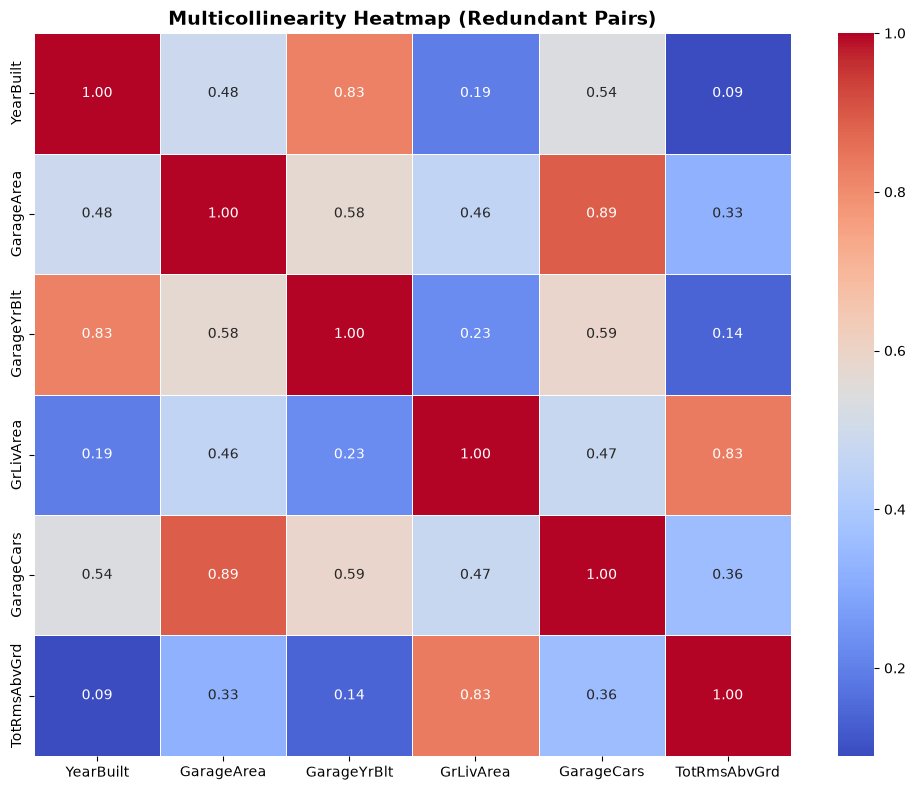

In [6]:
# 1. Isolate predictors (exclude target columns)
predictor_cols = [
    col for col in numeric_cols if col not in ['SalePrice', 'SalePrice_Log']
]
pred_corr = df[predictor_cols].corr()

# 2. Find pairs with absolute correlation > 0.80
high_corr_pairs = []
cols = pred_corr.columns

for i in range(len(cols)):
  for j in range(i + 1, len(cols)):
    feat1, feat2 = cols[i], cols[j]
    corr_val = pred_corr.iloc[i, j]

    if abs(corr_val) > 0.80:
      # Keep the feature that correlates more strongly with the target
      t_corr1 = abs(saleprice_corr.get(feat1, 0))
      t_corr2 = abs(saleprice_corr.get(feat2, 0))
      keep, drop = (
          (feat1, feat2) if t_corr1 >= t_corr2 else (feat2, feat1)
      )

      high_corr_pairs.append({
          'Feature_1': feat1,
          'Feature_2': feat2,
          'Correlation': corr_val,
          'Keep': keep,
          'Drop': drop,
      })

high_corr_df = pd.DataFrame(high_corr_pairs)

# 3. Print Results
if not high_corr_df.empty:
  print('=' * 70)
  print(' HIGHLY CORRELATED PREDICTOR PAIRS (|r| > 0.80)')
  print('=' * 70)
  print(
      high_corr_df.sort_values('Correlation', ascending=False).to_string(
          index=False
      )
  )
else:
  print('No redundant feature pairs found above 0.80.')

# 4. Quick Heatmap of Redundant Features
if not high_corr_df.empty:
  red_features = list(
      set(high_corr_df['Feature_1'].tolist() + high_corr_df['Feature_2'].tolist())
  )
  plt.figure(figsize=(10, 8))
  sns.heatmap(
      df[red_features].corr(),
      annot=True,
      cmap='coolwarm',
      fmt='.2f',
      linewidths=0.5,
  )
  plt.title(
      'Multicollinearity Heatmap (Redundant Pairs)',
      fontsize=14,
      fontweight='bold',
  )
  plt.tight_layout()
  plt.show()

# DROP REDUNDANT COLUMNS & SAVE PHASE 4 DATASET

In [7]:


# 1. Specify the list of columns you want to hardcode and drop
# (Example: replace these with the actual drop candidates flagged by your multicollinearity check)
columns_to_drop = ['TotRmsAbvGrd','GarageArea','GarageYrBlt']  # <-- Type your columns here

# 2. Drop the columns from your training dataframe
# errors='ignore' ensures code doesn't crash if a column isn't found
output_path = '../data/train_processed_phase4.csv'
# 3. Save the newly cleaned dataframe for Phase 5
train_model = df.drop(columns=columns_to_drop, errors='ignore')
# train_model=df

train_model.to_csv(output_path, index=False)

print('=' * 60)
print('✅ COLUMNS DROPPED & DATASET SAVED SUCCESSFULLY!')
print('=' * 60)
print(f'• Dropped columns: {columns_to_drop}')
print(f'• New dataset shape: {train_model.shape}')
print(f'• Saved file path: {output_path}')

✅ COLUMNS DROPPED & DATASET SAVED SUCCESSFULLY!
• Dropped columns: ['TotRmsAbvGrd', 'GarageArea', 'GarageYrBlt']
• New dataset shape: (1456, 79)
• Saved file path: ../data/train_processed_phase4.csv
